# Observable estimation and statistical uncertainty

In this notebook we will cover standard approaches for estimating expectation values of Pauli observables from finite-shot measurements and for quantifying the corresponding statistical uncertainty.

**NOTE:** the BONUS section and the final exercise cover more advanced material. They are not required preparation for the School, but they may be useful if you would like to explore statistical inference in more depth.


### Packages

Before using this notebook, make sure the following packages are installed in your Python environment:

- `qiskit` (versions 2.1.2 and 2.3.0 were tested by the notebook author)
- `qiskit-aer` (version 0.17.2)
- `numpy`
- `scipy`
- `matplotlib`
- `pylatexenc`

If you have trouble installing the packages locally, you can run the notebook on [Google Colab](https://colab.research.google.com). In that case, run the following cell once before proceeding.


In [ ]:
%pip install --quiet "qiskit==2.1.2" "qiskit-aer==0.17.2" numpy scipy matplotlib pylatexenc


### Reference calculation using NumPy and a statevector simulator

We will prepare the following two-qubit state:

$$
|\Psi(\theta)\rangle = \cos(\theta)|01\rangle+\sin(\theta)|10\rangle,
$$

and estimate several Pauli expectation values on it.

Throughout the analytical formulas in this notebook, we label basis states as $|q_0q_1\rangle$. Qiskit, however, displays bit strings and orders statevector amplitudes with qubit $0$ as the least-significant (rightmost) bit. Consequently, when we construct vectors explicitly with Kronecker products, qubit $1$ appears on the left and qubit $0$ on the right.


In [1]:
# let's code the ideal circuit in numpy first
import numpy as np

# we start defining all the Pauli observables
I = np.eye(2)
X = np.array([[0,1],[1,0]],dtype=complex)
Y = np.array([[0,-1.j],[1.j,0]],dtype=complex)
Z = np.array([[1,0],[0,-1]],dtype=complex)
# and now all possible two-qubit Pauli observables
# Qiskit statevectors use the tensor-product order q_1 \otimes q_0, so qubit 0 is the right factor.
X_1 = np.kron(X,I); Y_1 = np.kron(Y,I); Z_1 = np.kron(Z,I)
X_0 = np.kron(I,X); Y_0 = np.kron(I,Y); Z_0 = np.kron(I,Z)
X_0X_1 = np.kron(X,X); Y_0X_1 = np.kron(X,Y); Z_0X_1 = np.kron(X,Z)
X_0Y_1 = np.kron(Y,X); Y_0Y_1 = np.kron(Y,Y); Z_0Y_1 = np.kron(Y,Z)
X_0Z_1 = np.kron(Z,X); Y_0Z_1 = np.kron(Z,Y); Z_0Z_1 = np.kron(Z,Z)

In [2]:
# these are the computational states
zero_state=np.array([1,0])
one_state=np.array([0,1])
# and with Pauli X we can map one into the other, for instance
print(X@zero_state)

[0.+0.j 1.+0.j]


In [3]:
theta = 0.5
# In analytical notation these are |q_0 q_1> = |01> and |10>.
# In the statevector, Qiskit stores the tensor factors as q_1 \otimes q_0.
state_01 = np.kron(one_state, zero_state)
state_10 = np.kron(zero_state, one_state)

# This is our target state.
psi_theta = np.cos(theta)*state_01 + np.sin(theta)*state_10

In [4]:
## now we print all the possible Pauli expectation values on this state
print(f"<X_0>: {np.vdot(psi_theta,X_0@psi_theta)}\t<X_1>: {np.vdot(psi_theta,X_1@psi_theta)}")
print(f"<Y_0>: {np.vdot(psi_theta,Y_0@psi_theta)}\t<Y_1>: {np.vdot(psi_theta,Y_1@psi_theta)}")
print(f"<Z_0>: {np.vdot(psi_theta,Z_0@psi_theta)}\t<Z_1>: {np.vdot(psi_theta,Z_1@psi_theta)}")
print(f"<X_0X_1>: {np.vdot(psi_theta,X_0X_1@psi_theta)}\t \
        <X_0Y_1>: {np.vdot(psi_theta,X_0Y_1@psi_theta)}\t \
        <X_0Z_1>: {np.vdot(psi_theta,X_0Z_1@psi_theta)}")
print(f"<Y_0X_1>: {np.vdot(psi_theta,Y_0X_1@psi_theta)}\t \
        <Y_0Y_1>: {np.vdot(psi_theta,Y_0Y_1@psi_theta)}\t \
        <Y_0Z_1>: {np.vdot(psi_theta,Y_0Z_1@psi_theta)}")
print(f"<Z_0X_1>: {np.vdot(psi_theta,Z_0X_1@psi_theta)}\t \
        <Z_0Y_1>: {np.vdot(psi_theta,Z_0Y_1@psi_theta)}\t \
        <Z_0Z_1>: {np.vdot(psi_theta,Z_0Z_1@psi_theta)}")

<X_0>: 0j	<X_1>: 0j
<Y_0>: 0j	<Y_1>: 0j
<Z_0>: (0.5403023058681398+0j)	<Z_1>: (-0.5403023058681398+0j)
<X_0X_1>: (0.8414709848078965+0j)	         <X_0Y_1>: 2.5802204073195862e-17j	         <X_0Z_1>: 0j
<Y_0X_1>: -2.5802204073195862e-17j	         <Y_0Y_1>: (0.8414709848078965+0j)	         <Y_0Z_1>: 0j
<Z_0X_1>: 0j	         <Z_0Y_1>: 0j	         <Z_0Z_1>: (-1+0j)


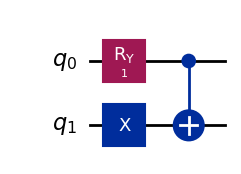

In [5]:
from qiskit import transpile
from qiskit import QuantumCircuit

circuitA = QuantumCircuit(2)
## note the factor of 2 needed to comply with qiskit conventions
circuitA.ry(2*theta,0)
circuitA.x(1)
circuitA.cx(0, 1)

circuitA.draw('mpl')

To extract the ideal statevector, we use Qiskit Aer and make a copy of the circuit. The `save_statevector()` instruction is added only to the copy, so the original circuit remains unchanged.


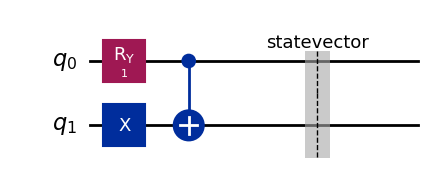

In [6]:
from qiskit_aer import AerSimulator

circuitA_sv = circuitA.copy()
circuitA_sv.save_statevector()
circuitA_sv.draw('mpl')

In [7]:
# Run the statevector simulator and extract the resulting vector.
sim_statevector = AerSimulator(method='statevector')
transpiled_circuitA_sv = transpile(circuitA_sv, sim_statevector)
job_sv = sim_statevector.run(transpiled_circuitA_sv)
result_sv = job_sv.result()
outputstate_sv = result_sv.get_statevector(transpiled_circuitA_sv)

# Convert the Qiskit Statevector object to a NumPy array.
psi_sv = np.asarray(outputstate_sv)
print(psi_sv)

[0.        +0.j 0.47942554+0.j 0.87758256+0.j 0.        +0.j]


Now we can evaluate the Pauli expectation values from the statevector.


In [8]:
print(f"<X_0>: {np.vdot(psi_sv,X_0@psi_sv)}\t<X_1>: {np.vdot(psi_sv,X_1@psi_sv)}")
print(f"<Y_0>: {np.vdot(psi_sv,Y_0@psi_sv)}\t<Y_1>: {np.vdot(psi_sv,Y_1@psi_sv)}")
print(f"<Z_0>: {np.vdot(psi_sv,Z_0@psi_sv)}\t<Z_1>: {np.vdot(psi_sv,Z_1@psi_sv)}")
print(f"<X_0X_1>: {np.vdot(psi_sv,X_0X_1@psi_sv)}\t \
        <X_0Y_1>: {np.vdot(psi_sv,X_0Y_1@psi_sv)}\t \
        <X_0Z_1>: {np.vdot(psi_sv,X_0Z_1@psi_sv)}")
print(f"<Y_0X_1>: {np.vdot(psi_sv,Y_0X_1@psi_sv)}\t \
        <Y_0Y_1>: {np.vdot(psi_sv,Y_0Y_1@psi_sv)}\t \
        <Y_0Z_1>: {np.vdot(psi_sv,Y_0Z_1@psi_sv)}")
print(f"<Z_0X_1>: {np.vdot(psi_sv,Z_0X_1@psi_sv)}\t \
        <Z_0Y_1>: {np.vdot(psi_sv,Z_0Y_1@psi_sv)}\t \
        <Z_0Z_1>: {np.vdot(psi_sv,Z_0Z_1@psi_sv)}")

<X_0>: 0j	<X_1>: 0j
<Y_0>: 0j	<Y_1>: 0j
<Z_0>: (0.5403023058681398+0j)	<Z_1>: (-0.5403023058681398+0j)
<X_0X_1>: (0.8414709848078965+0j)	         <X_0Y_1>: 2.5802204073195862e-17j	         <X_0Z_1>: 0j
<Y_0X_1>: -2.5802204073195862e-17j	         <Y_0Y_1>: (0.8414709848078965+0j)	         <Y_0Z_1>: 0j
<Z_0X_1>: 0j	         <Z_0Y_1>: 0j	         <Z_0Z_1>: (-1+0j)


Within numerical precision, the NumPy calculation and the Qiskit statevector calculation should agree.


### Initialize a backend with specified connectivity

We generate a local fake backend with a star-like connectivity similar to the one used in the previous preparatory notebook.


In [9]:
from qiskit.providers.fake_provider import GenericBackendV2

# Physical links of the star-like five-qubit device.
lagrange_edges = [(0, 2), (1, 2), (2, 3), (2, 4)]

# Coupling maps are directed in Qiskit. Since CZ is symmetric, represent
# every physical link in both directions.
lagrange_bidirectional_edges = lagrange_edges + [(b, a) for a, b in lagrange_edges]

fake_lagrange_backend = GenericBackendV2(
    num_qubits=5,
    coupling_map=lagrange_bidirectional_edges,
    basis_gates=["id", "rz", "sx", "x", "cz"]
)

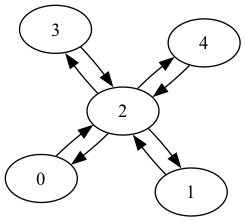

In [10]:
# We can plot the coupling map directly using its draw method.
fake_lagrange_backend.coupling_map.draw()

# Sampling with a finite number of shots


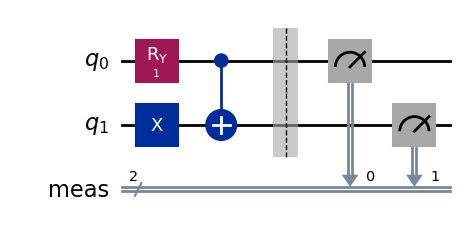

In [11]:
## let's now add measurements at the end of the circuit
circuitA_measZ = circuitA.copy()
circuitA_measZ.measure_all()
circuitA_measZ.draw('mpl')

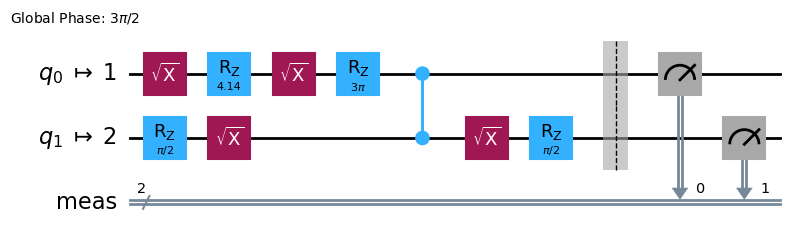

In [12]:
from qiskit import transpile
transpiled_circuitA_measZ = transpile(circuitA_measZ, backend=fake_lagrange_backend,optimization_level=2)
transpiled_circuitA_measZ.draw('mpl')

We can now generate finite-shot counts with the ideal Aer simulator. The circuit has already been transpiled to the gate set and connectivity of the fake backend.


In [13]:
## here we fix the random seed to a fixed random number for reproducibility
sample_job = sim_statevector.run([transpiled_circuitA_measZ],shots=1024,seed_simulator=21)
counts_circuitA_measZ = sample_job.result().get_counts()

These are the resulting counts.


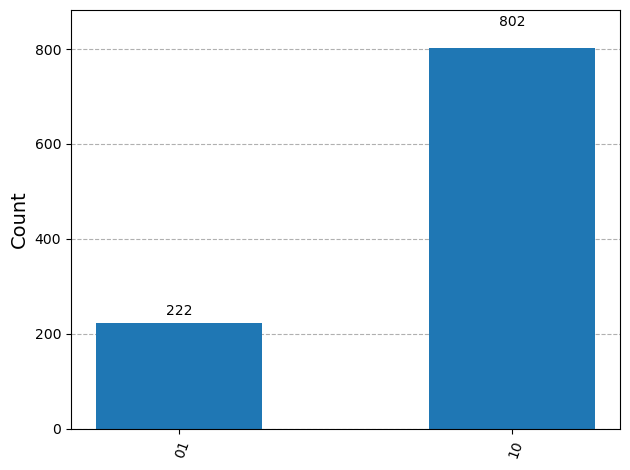

In [14]:
from qiskit.visualization import plot_histogram
plot_histogram(counts_circuitA_measZ)

A computational-basis measurement directly gives access to observables that are diagonal in the $Z$ basis. We first need to convert each measured bit string into the corresponding eigenvalue. For $Z_0$, a straightforward explicit map is:


In [15]:
counts_to_Z0 = {
    '00': 1.0,
    '01': -1.0,
    '10': 1.0,
    '11': -1.0
}

At this point we can estimate the empirical expectation value.


In [16]:
average_Z0 = 0.0
tot_counts = 0
for cc in counts_circuitA_measZ:
    ## for every bit-string we measure we compute the corresponding value
    value = counts_to_Z0[cc]
    ## and accumulate the result by multiplying the number of counts
    average_Z0 += counts_circuitA_measZ[cc]*value
    ## together with the cumulative number of counts
    tot_counts += counts_circuitA_measZ[cc]
## we finish by dividing by the total number of counts
average_Z0 /= tot_counts
print(f"<Z_0> = {average_Z0}\t [ideal was: {np.vdot(psi_sv,Z_0@psi_sv)}]")

<Z_0> = 0.56640625	 [ideal was: (0.5403023058681398+0j)]


The explicit dictionary above does not scale well: for an $n$-qubit bit string it would contain $2^n$ entries. A better strategy is to compute the eigenvalue directly from the measured bits.

For the $Z_0$ operator,

$$
\lambda\left(Z_0,\mathrm{bits}\right) = (-1)^{\mathrm{bits}[0]},
$$

where $\mathrm{bits}[0]$ denotes the measured value of qubit $0$.

**Qiskit bit ordering:** in a displayed count string, qubit $0$ is the **rightmost** bit. Therefore, if the string is converted to a Python list from left to right, the entry associated with qubit $q$ is at position `num_qubits - 1 - q`.

For an arbitrary product of $Z$ operators, the corresponding eigenvalue can be computed on the fly from the parity of the selected bits:

$$
\lambda\left(\prod_{k=0}^{M-1}Z_{q_k},\mathrm{bits}\right)
= (-1)^{\sum_{k=0}^{M-1}\mathrm{bits}[q_k]}.
$$

A convenient implementation is therefore to store the qubit indices that appear in the observable. For instance:


In [17]:
bits_for_Z_0 = [0]
average_Z0 = 0.0
tot_counts = 0
for cc in counts_circuitA_measZ:
    ## convert the measured bit-string into a list of numerical values
    int_bit_string = [int(bb) for bb in cc]
    ## compute the sum of bits (note the ordering convention)
    num_qubits = len(int_bit_string)
    exp_sum = sum([int_bit_string[num_qubits-1-bit] for bit in bits_for_Z_0])
    ## convert this into the corresponding value
    value = (-1)**exp_sum
    ## and accumulate the result by multiplying the number of counts
    average_Z0 += counts_circuitA_measZ[cc]*value
    ## together with the cumulative number of counts
    tot_counts += counts_circuitA_measZ[cc]
## we finish by dividing by the total number of counts
average_Z0 /= tot_counts
print(f"<Z_0> = {average_Z0}\t [ideal was: {np.vdot(psi_sv,Z_0@psi_sv)}]")

<Z_0> = 0.56640625	 [ideal was: (0.5403023058681398+0j)]


Since we will perform the same calculation for several Pauli observables, it is useful to define a helper function.


In [18]:
def exp_from_counts(input_counts, bits_for_observable):
    average_obs = 0.0
    tot_counts = 0
    for cc in input_counts:
        ## convert the measured bit-string into a list of numerical values
        int_bit_string = [int(bb) for bb in cc]
        ## compute the sum of bits (note the ordering convention)
        num_qubits = len(int_bit_string)
        exp_sum = sum([int_bit_string[num_qubits-1-bit] for bit in bits_for_observable])
        ## convert this into the corresponding value
        value = (-1)**exp_sum
        ## and accumulate the result by multiplying the number of counts
        average_obs += input_counts[cc]*value
        ## together with the cumulative number of counts
        tot_counts += input_counts[cc]
    ## we finish by dividing by the total number of counts
    average_obs /= tot_counts

    return average_obs

Let us check that this reproduces the expectation values of the diagonal Pauli observables.


In [19]:
print(f"<Z_0> = {exp_from_counts(counts_circuitA_measZ,[0])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_0@psi_sv))}]")
print(f"<Z_1> = {exp_from_counts(counts_circuitA_measZ,[1])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_1@psi_sv))}]")
print(f"<Z_0Z_1> = {exp_from_counts(counts_circuitA_measZ,[0,1])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_0Z_1@psi_sv))}]")

<Z_0> = 0.56640625	 [ideal was: 0.5403023058681398]
<Z_1> = -0.56640625	 [ideal was: -0.5403023058681398]
<Z_0Z_1> = -1.0	 [ideal was: -1.0]


### Measuring off-diagonal Pauli operators

To measure an operator that is not diagonal in the computational basis, we first rotate its eigenbasis into the $Z$ basis and then measure.


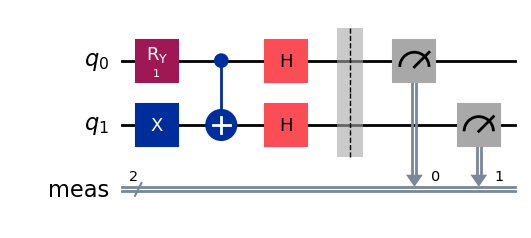

In [20]:
## let's now add measurements at the end of the circuit
circuitA_measX = circuitA.copy()
## change from X basis to Z basis with Hadamards
circuitA_measX.h([0,1])
circuitA_measX.measure_all()
circuitA_measX.draw('mpl')

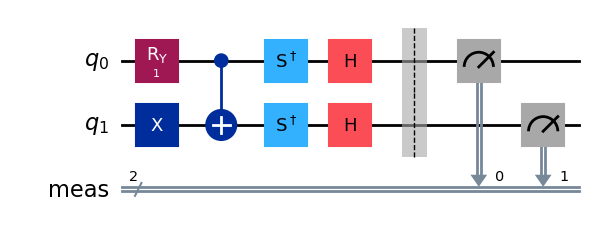

In [21]:
## let's now add measurements at the end of the circuit
circuitA_measY = circuitA.copy()
## change from Y basis to Z basis with S^\dagger and Hadamards
circuitA_measY.sdg([0,1])
circuitA_measY.h([0,1])
circuitA_measY.measure_all()
circuitA_measY.draw('mpl')

Instead of submitting each measurement circuit separately, we can execute several circuits in a single simulator job. For instance:


In [22]:
## we first make a list of the circuits we want
circuit_list = [circuitA_measX,circuitA_measY,circuitA_measZ]
## we then transpile them
transpiled_circuitA_measXYZ = []
for circ in circuit_list:
    transpiled_circuitA_measXYZ.append(transpile(circ, backend=fake_lagrange_backend,optimization_level=2))
## now we can run them in a single job
## here we fix the random seed to a fixed random number for reproducibility
sample_job = sim_statevector.run(transpiled_circuitA_measXYZ,shots=1024,seed_simulator=21)

In [23]:
## we now have a list of counts from running the job
sample_job.result().get_counts()

[{'10': 42, '11': 491, '00': 443, '01': 48},
 {'01': 36, '10': 35, '00': 451, '11': 502},
 {'10': 788, '01': 236}]

In [24]:
xcounts = sample_job.result().get_counts()[0]
print(f"<X_0> = {exp_from_counts(xcounts,[0])}\t [ideal was: {np.real(np.vdot(psi_sv,X_0@psi_sv))}]")
print(f"<X_1> = {exp_from_counts(xcounts,[1])}\t [ideal was: {np.real(np.vdot(psi_sv,X_1@psi_sv))}]")
print(f"<X_0X_1> = {exp_from_counts(xcounts,[0,1])}\t [ideal was: {np.real(np.vdot(psi_sv,X_0X_1@psi_sv))}]")

<X_0> = -0.052734375	 [ideal was: 0.0]
<X_1> = -0.041015625	 [ideal was: 0.0]
<X_0X_1> = 0.82421875	 [ideal was: 0.8414709848078965]


In [25]:
ycounts = sample_job.result().get_counts()[1]
print(f"<Y_0> = {exp_from_counts(ycounts,[0])}\t [ideal was: {np.real(np.vdot(psi_sv,Y_0@psi_sv))}]")
print(f"<Y_1> = {exp_from_counts(ycounts,[1])}\t [ideal was: {np.real(np.vdot(psi_sv,Y_1@psi_sv))}]")
print(f"<Y_0Y_1> = {exp_from_counts(ycounts,[0,1])}\t [ideal was: {np.real(np.vdot(psi_sv,Y_0Y_1@psi_sv))}]")

<Y_0> = -0.05078125	 [ideal was: 0.0]
<Y_1> = -0.048828125	 [ideal was: 0.0]
<Y_0Y_1> = 0.861328125	 [ideal was: 0.8414709848078965]


In [26]:
zcounts = sample_job.result().get_counts()[2]
print(f"<Z_0> = {exp_from_counts(zcounts,[0])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_0@psi_sv))}]")
print(f"<Z_1> = {exp_from_counts(zcounts,[1])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_1@psi_sv))}]")
print(f"<Z_0Z_1> = {exp_from_counts(zcounts,[0,1])}\t [ideal was: {np.real(np.vdot(psi_sv,Z_0Z_1@psi_sv))}]")

<Z_0> = 0.5390625	 [ideal was: 0.5403023058681398]
<Z_1> = -0.5390625	 [ideal was: -0.5403023058681398]
<Z_0Z_1> = -1.0	 [ideal was: -1.0]


- **EXERCISE 1:** How many separate measurement circuits are needed to estimate all two-qubit Pauli expectation values?
- **EXERCISE 2:** For the state considered above, the only non-zero Pauli expectation values are $\langle Z_0\rangle$, $\langle Z_1\rangle$, $\langle Z_0Z_1\rangle$, $\langle X_0X_1\rangle$, and $\langle Y_0Y_1\rangle$. Show that only two independent measurement circuits are sufficient. Implement them and verify that they reproduce all five expectation values.


# Estimating statistical errors
### The direct way

The expectation values estimated above fluctuate because we use only a finite number of shots. For a Pauli observable, each shot produces an eigenvalue $\lambda_j=\pm1$. If

$$
\overline{P}=\frac{1}{N_{\mathrm{shots}}}\sum_{j=1}^{N_{\mathrm{shots}}}\lambda_j
$$

is the sample mean, then the empirical second moment is exactly one:

$$
\frac{1}{N_{\mathrm{shots}}}\sum_{j=1}^{N_{\mathrm{shots}}}\lambda_j^2=1.
$$

The unbiased sample variance of the **single-shot outcomes** is therefore

$$
s_P^2=\frac{N_{\mathrm{shots}}}{N_{\mathrm{shots}}-1}
\left(1-\overline{P}^{\,2}\right).
$$

The corresponding estimated variance of the sample mean is

$$
\widehat{\mathrm{Var}}[\overline{P}]
=\frac{s_P^2}{N_{\mathrm{shots}}}
=\frac{1-\overline{P}^{\,2}}{N_{\mathrm{shots}}-1},
$$

so an estimate of the standard error is

$$
\epsilon_P=\sqrt{\frac{1-\overline{P}^{\,2}}{N_{\mathrm{shots}}-1}}.
$$

The Central Limit Theorem is not needed to derive this variance estimator. It becomes relevant when we use the standard error to construct an approximately Gaussian confidence interval for the expectation value. Such a Gaussian approximation can be poor for small samples or when the underlying probability is very close to $0$ or $1$.

**NOTE:** there is no need to rerun the same circuit many times merely to estimate the variance of the sample mean. The shot outcomes from a single job already contain the information needed for the estimators above.


- **EXERCISE 3:** Extend the function `exp_from_counts` so that it returns an estimate of the statistical error together with the expectation value.
- **EXERCISE 4:** Write a function that, given a list of $M$ diagonal Pauli operators $[P_1,P_2,\dots,P_M]$ and $M$ real coefficients $[\beta_1,\beta_2,\dots,\beta_M]$, computes the expectation value and an error estimate for

$$
O\left(\vec{\beta}\right)=\sum_{m=1}^M\beta_m P_m.
$$


### The binomial way

Estimating the expectation value of a Pauli observable can also be formulated as a binomial statistical-inference problem. A Pauli operator $P$ has eigenvalues $\pm1$, so it can be written as

$$
P=\Pi_{+}-\Pi_{-}=\Pi_{+}-\left(\mathbb{1}-\Pi_{+}\right)=2\Pi_{+}-\mathbb{1},
$$

where $\Pi_{+}$ and $\Pi_{-}$ project onto the $+1$ and $-1$ eigenspaces, respectively.

For example, for $Z_0$ on two qubits,

$$
\langle Z_0\rangle=2p_0-1,
\qquad
p_0=\left\langle\mathbb{1}\otimes|0\rangle\langle0|\right\rangle,
$$

where $p_0$ is the probability of measuring qubit $0$ in state $|0\rangle$. Here the tensor-product order follows Qiskit's statevector convention, with qubit $0$ on the right.

For this $Z_0$ example, every shot can be viewed as a Bernoulli trial: a "success" occurs when qubit $0$ is measured as $0$, with probability $p_0$. If $N_{\mathrm{success}}$ successes are observed in $N_{\mathrm{shots}}$ measurements, the maximum-likelihood estimator is

$$
\widehat{p_0}=\frac{N_{\mathrm{success}}}{N_{\mathrm{shots}}}.
$$

Using the plug-in estimate for the binomial variance gives

$$
\widehat{\mathrm{Var}}\left[\widehat{p_0}\right]
=\frac{\widehat{p_0}\left(1-\widehat{p_0}\right)}{N_{\mathrm{shots}}}.
$$

Let us use these expressions in practice.


In [27]:
# Specify which qubit must be measured in state |0> for this probability.
bits_for_Z_0 = [0]

# Estimate p_0 from counts.
tot_shots = sum(zcounts.values())
pi_shots = 0
for kk in zcounts:
    num_qubits = len(kk)
    bit_values = np.array([int(kk[num_qubits-1-bit]) for bit in bits_for_Z_0])
    pi_shots += zcounts[kk] * np.all(bit_values == 0)

p0_sample = pi_shots/tot_shots
err_p0_sample = np.sqrt(p0_sample*(1.-p0_sample)/tot_shots)
print(f"Sample estimate for p_0: {p0_sample} +- {err_p0_sample}")
print(f"Sample estimate for Z_0 from p_0: {2*p0_sample-1} +- {2*err_p0_sample}")

Sample estimate for p_0: 0.76953125 +- 0.013160402598556447
Sample estimate for Z_0 from p_0: 0.5390625 +- 0.026320805197112895


Since we will use the same calculation more than once, let us define a helper function.


In [28]:
def prob_and_err_from_counts(input_counts, bits_required_zero):
    tot_counts = sum(input_counts.values())
    success_counts = 0.0

    for cc in input_counts:
        num_qubits = len(cc)
        bit_values = np.array(
            [int(cc[num_qubits-1-bit]) for bit in bits_required_zero]
        )
        success_counts += input_counts[cc] * np.all(bit_values == 0)

    prob = success_counts/tot_counts
    prob_err = np.sqrt(prob*(1.-prob)/tot_counts)

    return prob, prob_err

In [29]:
prob_and_err = prob_and_err_from_counts(zcounts, [0])
print(f"Sample estimate for p_0: {prob_and_err[0]} +- {prob_and_err[1]}")
print(f"Sample estimate for Z_0 from p_0: {2*prob_and_err[0]-1} +- {2*prob_and_err[1]}")

Sample estimate for p_0: 0.76953125 +- 0.013160402598556447
Sample estimate for Z_0 from p_0: 0.5390625 +- 0.026320805197112895


The estimation of probabilities will be a central topic when we discuss error mitigation during the School. Here, however, our goal is to estimate $\langle Z_0\rangle$ and its statistical uncertainty. Since

$$
\widehat{\langle Z_0\rangle}=2\widehat{p_0}-1,
$$

the plug-in variance estimate gives

$$
\epsilon_{Z_0}
=2\sqrt{\frac{\widehat{p_0}(1-\widehat{p_0})}{N_{\mathrm{shots}}}}
=\sqrt{\frac{1-\widehat{\langle Z_0\rangle}^{\,2}}{N_{\mathrm{shots}}}}.
$$

Compared with the unbiased estimator in the previous section, this expression has $N_{\mathrm{shots}}$ rather than $N_{\mathrm{shots}}-1$ in the denominator. It is therefore the corresponding biased plug-in estimate of the variance of the sample mean.


### BONUS: The Bayesian way

The previous section related the estimation of a Pauli expectation value to estimation of the success probability of a binomial distribution. We now use the same idea in a Bayesian setting.

For the $Z_0$ example, the probability of observing $N_{\mathrm{success}}$ shots in which qubit $0$ is measured as $|0\rangle$, out of $N_{\mathrm{shots}}$ trials, is

$$
P(N_{\mathrm{success}}\mid N_{\mathrm{shots}},p_0)
=\binom{N_{\mathrm{shots}}}{N_{\mathrm{success}}}
 p_0^{N_{\mathrm{success}}}(1-p_0)^{N_{\mathrm{shots}}-N_{\mathrm{success}}}.
$$

For fixed observed data this is the likelihood as a function of the unknown probability $p_0$. The maximum-likelihood point estimator is

$$
\widehat{p_0}^{\mathrm{MLE}}=\frac{N_{\mathrm{success}}}{N_{\mathrm{shots}}}.
$$

In Bayesian inference, instead, we seek a posterior distribution for the parameter:

$$
P(p_0\mid N_{\mathrm{success}},N_{\mathrm{shots}})
\propto
P(N_{\mathrm{success}}\mid N_{\mathrm{shots}},p_0)P(p_0),
$$

where $P(p_0)$ is the prior distribution. The normalization factor is the marginal likelihood (also called the evidence).


For some likelihoods there are convenient **conjugate priors**, for which the posterior belongs to the same family as the prior. For a binomial likelihood, the conjugate prior is the Beta distribution

$$
P_{\mathrm{Beta}}(p\mid\alpha,\beta)
=\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}
 p^{\alpha-1}(1-p)^{\beta-1},
$$

with positive parameters $\alpha$ and $\beta$.

If the prior is $\mathrm{Beta}(\alpha,\beta)$, the posterior is

$$
p_0\mid N_{\mathrm{success}},N_{\mathrm{shots}}
\sim
\mathrm{Beta}\!\left(
\alpha+N_{\mathrm{success}},
\beta+N_{\mathrm{shots}}-N_{\mathrm{success}}
\right).
$$

The prior encodes what we assume about $p_0$ before looking at the data. A simple choice when we want a prior that is uniform over $[0,1]$ is $\alpha=\beta=1$.


The posterior mean can be used as a Bayesian point estimator:

$$
\widehat{p_0}^{\mathrm{Bayes}}
=\frac{N_{\mathrm{success}}+\alpha}{N_{\mathrm{shots}}+\alpha+\beta}
\xrightarrow{\alpha=\beta=1}
\frac{N_{\mathrm{success}}+1}{N_{\mathrm{shots}}+2}.
$$

Algebraically, this posterior mean can be interpreted as adding $\alpha$ prior successes and $\beta$ prior failures to the observed counts.

More importantly, the posterior distribution allows us to construct a **credible interval** for $p_0$. A Bayesian credible interval and a frequentist confidence interval have different statistical interpretations, even when they become numerically similar in a large-sample regime. The posterior can also be sampled and propagated through nonlinear functions of $p_0$, which will be useful below for the entanglement entropy example.

Let us now look at one example for estimating $\langle Z_0\rangle$.


In [30]:
## these are the counts containing information about Z_0
print(zcounts)
## let's extract N_success and N_shots from it in the same way we did before
N_shots = sum([zcounts[kk] for kk in zcounts.keys()])
N_success = 0
for kk in zcounts.keys():
    num_qubits = len(kk)
    bit_values = np.array([int(kk[num_qubits-1-bit]) for bit in bits_for_Z_0])
    N_success += zcounts[kk]*np.all(bit_values==np.array([0]*len(bits_for_Z_0)))
print(f"For Z_0 we have: N_success = {N_success} \t N_shots = {N_shots}" )

{'10': 788, '01': 236}
For Z_0 we have: N_success = 788 	 N_shots = 1024


In [31]:
## import the Beta distribution from scipy
from scipy.stats import beta
## update posterior parameters starting from uniform prior
a = 1 + N_success
b = 1 + (N_shots - N_success)
## point estimator for p_0
print("Point estimators for p_0:")
print(f"\t maximum likelihood: {N_success/N_shots}")
print(f"\t Bayesian posterior: {beta.mean(a,b)}")

Point estimators for p_0:
	 maximum likelihood: 0.76953125
	 Bayesian posterior: 0.7690058479532164


Now we have the full posterior distribution, let's see how it looks

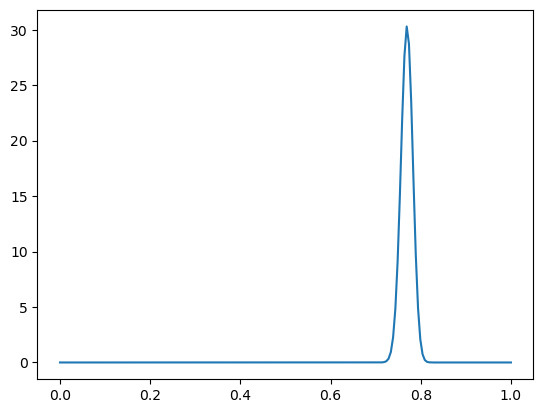

In [32]:
import matplotlib.pyplot as plt
prange = np.linspace(0,1,200)
plt.plot(prange,beta.pdf(prange,a,b))
plt.show()

We can now construct, for example, a central $68\%$ credible interval using the percent-point function (`ppf`) provided by SciPy.


In [33]:
prob = 0.68
low_p = 0.5*(1-prob)
high_p = 1-low_p
cr_int = beta.ppf([low_p, high_p], a, b)
print(f"Credible interval [68%] for p_0 is: [{cr_int[0]},{cr_int[1]}]")

p_mle = N_success/N_shots
var_mle = p_mle*(1.-p_mle)/N_shots
print(f"Mean and error from MLE: {p_mle} +- {np.sqrt(var_mle)}")
print(f"Approximate 68% Gaussian interval: [{p_mle-np.sqrt(var_mle)},{p_mle+np.sqrt(var_mle)}]")

Credible interval [68%] for p_0 is: [0.7559259819756676,0.7820893634696154]
Mean and error from MLE: 0.76953125 +- 0.013160402598556447
Approximate 68% Gaussian interval: [0.7563708474014436,0.7826916525985564]


We can compare the Bayesian posterior with the Gaussian approximation centered on the maximum-likelihood estimator. In this example they are difficult to distinguish visually.


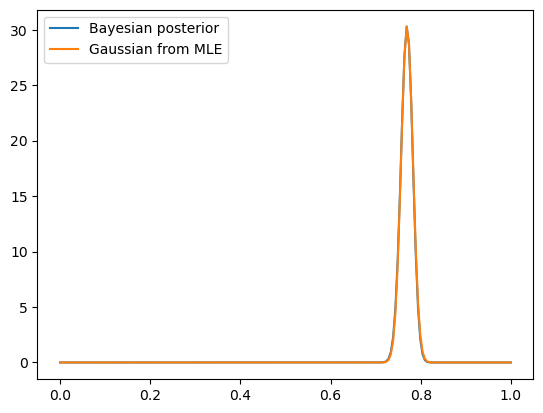

In [34]:
from scipy.stats import norm
prange = np.linspace(0,1,200)
plt.plot(prange,beta.pdf(prange,a,b),label="Bayesian posterior")
plt.plot(prange,norm.pdf(prange,loc=p_mle,scale=np.sqrt(var_mle)),label="Gaussian from MLE")
plt.legend()
plt.show()

For this parameter value and number of shots, the Gaussian approximation is therefore quite accurate. This need not remain true close to the boundary $p_0=0$ or $p_0=1$.

Let us change the angle $\theta$ and see what happens.


In [35]:
theta=0.97*np.pi/2
# this is our target state
psi_theta = np.cos(theta)*state_01+np.sin(theta)*state_10
z0_ave = np.real(np.vdot(psi_theta,Z_0@psi_theta))
print(f"<Z_0>: {z0_ave}\t p_0: {(z0_ave+1)/2}")

<Z_0>: -0.9955619646030801	 p_0: 0.0022190176984599463


In [36]:
# Prepare the circuit.
circuitB = QuantumCircuit(2)
circuitB.ry(2*theta, 0)
circuitB.x(1)
circuitB.cx(0, 1)
circuitB.measure_all()

# Transpile and run it.
transpiledB = transpile(circuitB, backend=fake_lagrange_backend, optimization_level=2)
sample_jobB = sim_statevector.run(transpiledB, shots=1024, seed_simulator=17)
zcountsB = sample_jobB.result().get_counts()
print(zcountsB)

# Extract N_success and N_shots for qubit 0.
N_shotsB = sum(zcountsB.values())
N_successB = 0
for kk in zcountsB:
    num_qubits = len(kk)
    bit_values = np.array([int(kk[num_qubits-1-bit]) for bit in bits_for_Z_0])
    N_successB += zcountsB[kk] * np.all(bit_values == 0)

print(f"For Z_0 we have: N_success = {N_successB} \t N_shots = {N_shotsB}")

{'10': 4, '01': 1020}
For Z_0 we have: N_success = 4 	 N_shots = 1024


In [37]:
# Update posterior parameters starting from a uniform prior.
a = 1 + N_successB
b = 1 + (N_shotsB - N_successB)

# Get a central credible interval.
prob = 0.68
low_p = 0.5*(1-prob)
high_p = 1-low_p
cr_int = beta.ppf([low_p, high_p], a, b)
print(f"Credible interval [68%] for p_0 is: [{cr_int[0]},{cr_int[1]}]")

p_mle = N_successB/N_shotsB
var_mle = p_mle*(1.-p_mle)/N_shotsB
print(f"Mean and error from MLE: {p_mle} +- {np.sqrt(var_mle)}")
print(f"Approximate 68% Gaussian interval: [{p_mle-np.sqrt(var_mle)},{p_mle+np.sqrt(var_mle)}]")

Credible interval [68%] for p_0 is: [0.0027808656755350485,0.006961967757119886]
Mean and error from MLE: 0.00390625 +- 0.0019493065701503066
Approximate 68% Gaussian interval: [0.001956943429849693,0.005855556570150307]


Near the boundary, the Bayesian credible interval and the Gaussian interval built around the maximum-likelihood estimate can differ much more noticeably. This is also visible in the shapes of the corresponding distributions.


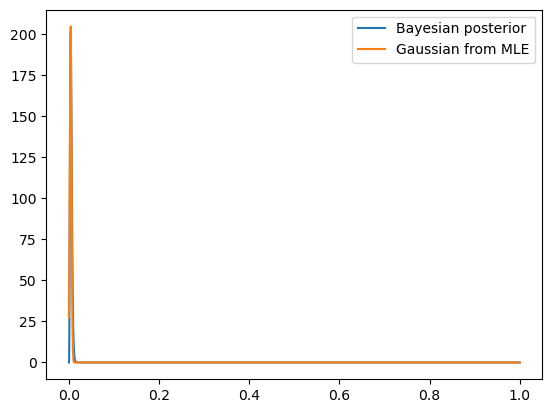

In [38]:
prange = np.linspace(0,1,2000)
plt.plot(prange,beta.pdf(prange,a,b),label="Bayesian posterior")
plt.plot(prange,norm.pdf(prange,loc=p_mle,scale=np.sqrt(var_mle)),label="Gaussian from MLE")
plt.legend()
plt.show()

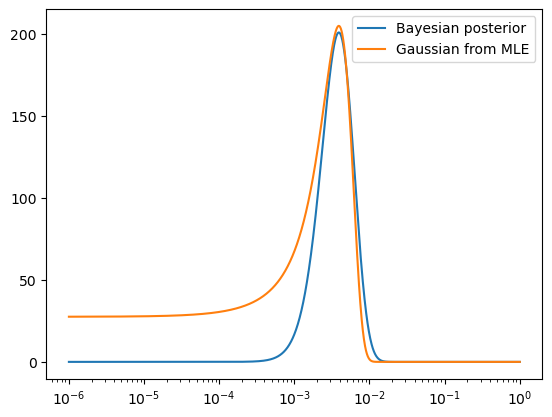

In [39]:
# Use a logarithmic x axis to zoom in near p_0 = 0.
prange_log = np.geomspace(1e-6, 1.0, 2000)
plt.semilogx(prange_log, beta.pdf(prange_log, a, b), label="Bayesian posterior")
plt.semilogx(prange_log, norm.pdf(prange_log, loc=p_mle, scale=np.sqrt(var_mle)), label="Gaussian from MLE")
plt.legend()
plt.show()

With enough shots, and away from parameter-space boundaries, Bayesian and Gaussian large-sample estimates often become numerically very similar. A Bayesian treatment can nevertheless be particularly convenient when

- we want intervals that automatically respect the physical range of a probability;
- several quantities are inferred from the same, correlated measurement outcomes;
- we want to propagate uncertainty through a nonlinear function of measured probabilities.

None of these tasks is exclusive to Bayesian statistics; the Bayesian formulation is simply one convenient way to treat them consistently.


For the first point, suppose we want intervals at different failure probabilities $p_f$. So far we have considered $p_f=0.32$, corresponding to a central $68\%$ interval, but we may want a more conservative confidence or credibility level. We can scan over $p_f$ as follows.


In [40]:
num_pts = 100
pf_range = np.linspace(0.005, 0.5, num_pts)

bayes_ci = np.zeros((num_pts, 2))
mle_ci = np.zeros((num_pts, 2))
for i in range(num_pts):
    low_p = 0.5*pf_range[i]
    high_p = 1-low_p

    # Bayesian central credible interval.
    bayes_ci[i, :] = beta.ppf([low_p, high_p], a, b)

    # Gaussian (Wald) interval around the MLE.
    zeta = norm.ppf(high_p)
    mle_ci[i, 0] = p_mle - zeta*np.sqrt(var_mle)
    mle_ci[i, 1] = p_mle + zeta*np.sqrt(var_mle)

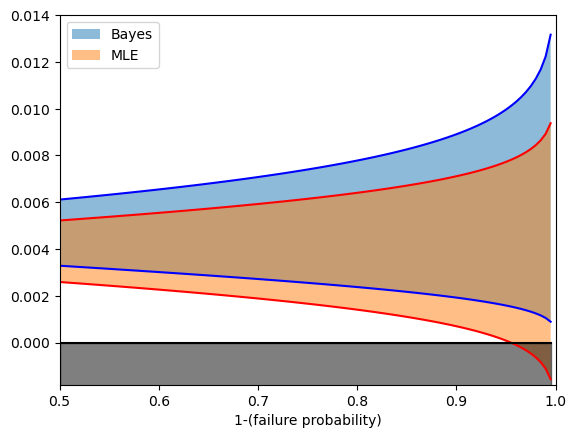

In [41]:
plt.plot(1-pf_range,bayes_ci[:,0],color='blue')
plt.plot(1-pf_range,bayes_ci[:,1],color='blue')
plt.fill_between(1-pf_range,bayes_ci[:,0],bayes_ci[:,1],alpha=0.5,label='Bayes')
plt.plot(1-pf_range,mle_ci[:,0],color='red')
plt.plot(1-pf_range,mle_ci[:,1],color='red')
plt.fill_between(1-pf_range,mle_ci[:,0],mle_ci[:,1],alpha=0.5,label='MLE')
plt.plot(1-pf_range,0.0*pf_range,color='black')
plt.fill_between(1-pf_range,-0.1*np.ones(len(pf_range)),0.0*pf_range,color='black',alpha=0.5)
plt.ylim([-0.0018,0.014])
plt.xlim([0.5,1.0])
plt.xlabel("1-(failure probability)")
plt.legend()
plt.show()

For small failure probabilities, the Gaussian (Wald) interval can extend outside the physical probability range $[0,1]$, for example to negative values. The Beta posterior, by construction, has support only on $[0,1]$, so its credible intervals remain within the physical domain.


A simple situation in which several estimators are statistically dependent occurs when we infer multiple observables from the same set of two-qubit measurement outcomes. For example, consider

$$
E(\alpha_1,\alpha_2,\alpha_3)
=\alpha_1\langle Z_0\rangle
+\alpha_2\langle Z_1\rangle
+\alpha_3\langle Z_0Z_1\rangle.
$$

Let $p_{q_0q_1}$ denote the probability of the outcome $|q_0q_1\rangle$ in the **analytical ordering used in this notebook**. Then

$$
\langle Z_0\rangle
=p_{00}+p_{01}-p_{10}-p_{11},
$$

$$
\langle Z_1\rangle
=p_{00}+p_{10}-p_{01}-p_{11},
$$

and

$$
\langle Z_0Z_1\rangle
=p_{00}+p_{11}-p_{01}-p_{10}.
$$

Equivalently, the probabilities of observing qubit $0$ or qubit $1$ in state $|0\rangle$ are

$$
p_0=p_{00}+p_{01},
\qquad
p_1=p_{00}+p_{10}.
$$

The four outcome probabilities are not independent because any probability distribution must satisfy

$$
p_{00}+p_{01}+p_{10}+p_{11}=1.
$$

This is not a problem for point estimators, but the correlations matter when propagating statistical uncertainty to a quantity such as $E$.

The Beta-binomial construction has a natural multivariate analogue: a multinomial likelihood together with a Dirichlet prior. The Dirichlet distribution is conjugate to the multinomial, so the Bayesian update can again be performed in closed form. One can then sample the posterior distribution of the four probabilities, evaluate $E$ on every sample, and infer a credible interval from the resulting samples.

Before considering the multivariate case, the following cells illustrate posterior sampling for a simple Beta distribution.


In [42]:
## define parameters alpha and beta for the posterior
a=120
b=300
## get credible interval
prob = 0.90
low_p = 0.5*(1-prob)
hig_p = 1-low_p
cr_int = beta.ppf([low_p,hig_p],a,b)
print(f"Exact 90% credible interval: [{cr_int[0]},{cr_int[1]}]")

Exact 90% credible interval: [0.2500831090773767,0.32250704909693273]


In [43]:
## produce num_samples samples of p_0 from its posterior
num_samples = 10000
p0_samples = beta.rvs(a,b,size=num_samples,random_state = 42) ## the last argument fixed random seed

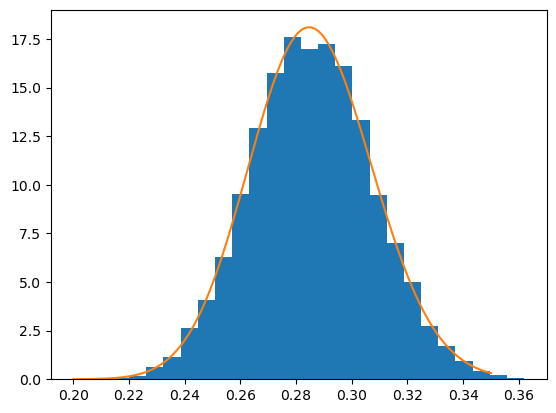

In [44]:
## compare empirical distribution with correct posterior
plt.hist(p0_samples, bins=25,density=True)
prange = np.linspace(0.2,0.35,200)
plt.plot(prange,beta.pdf(prange,a,b))

In [45]:
# Extract a 90% credible interval from samples.
sorted_samples = np.sort(p0_samples)

prob = 0.90
low_p = 0.5*(1-prob)
high_p = 1-low_p
cred_interval = [
    sorted_samples[int(low_p * num_samples)],
    sorted_samples[int(high_p * num_samples)]
]

# Compare the sample-based estimate with the exact interval.
print(f"Exact 90% credible interval: [{cr_int[0]},{cr_int[1]}]")
print(f"Estimated 90% credible interval: [{cred_interval[0]},{cred_interval[1]}]")

Exact 90% credible interval: [0.2500831090773767,0.32250704909693273]
Estimated 90% credible interval: [0.25010844503943624,0.3222196170183337]


- **BONUS EXERCISE:** estimation of entanglement entropy

As an example of using Bayesian inference to estimate credible intervals for a nonlinear function of measured probabilities, consider the entanglement entropy of qubit $0$ in the state $|\Psi(\theta)\rangle$ introduced at the beginning of the notebook.

Let

$$
\rho(\theta)=|\Psi(\theta)\rangle\langle\Psi(\theta)|.
$$

Using the analytical basis ordering $|q_0q_1\rangle$, the reduced density matrix of qubit $0$ is obtained by tracing out qubit $1$:

$$
\rho_0(\theta)=\mathrm{Tr}_1[\rho(\theta)]
=\sum_{q,p=0}^1 |q\rangle\langle p|
\left(
\langle q0|\rho(\theta)|p0\rangle
+\langle q1|\rho(\theta)|p1\rangle
\right).
$$

Any single-qubit density matrix can be written in terms of Pauli expectation values as

$$
\rho_0(\theta)
=\frac{1}{2}\left(
\mathbb{1}+\langle X_0\rangle X
+\langle Y_0\rangle Y
+\langle Z_0\rangle Z
\right).
$$

For the family of states considered in this notebook, $\langle X_0\rangle=\langle Y_0\rangle=0$, so $\rho_0(\theta)$ is diagonal. Its eigenvalues are

$$
\lambda_+=\frac{1+\langle Z_0\rangle}{2},
\qquad
\lambda_-=\frac{1-\langle Z_0\rangle}{2}.
$$

The von Neumann entropy is

$$
S(\rho)=-\mathrm{Tr}[\rho\log_2\rho],
$$

and therefore

$$
S(\rho_0(\theta))
=-\frac{1+\langle Z_0\rangle}{2}
\log_2\left(\frac{1+\langle Z_0\rangle}{2}\right)
-\frac{1-\langle Z_0\rangle}{2}
\log_2\left(\frac{1-\langle Z_0\rangle}{2}\right).
$$

Equivalently, if $p_0$ is the probability of measuring qubit $0$ in $|0\rangle$,

$$
S(\rho_0(\theta))
=-p_0\log_2(p_0)-(1-p_0)\log_2(1-p_0).
$$

A plug-in point estimator is obtained by replacing $p_0$ with its estimate $\widehat{p_0}$.

Estimate a credible interval for the entanglement entropy for several values of $\theta\in[0,\pi/2]$ by sampling $p_0$ from its posterior and transforming each posterior sample into an entropy value.

What would happen if you instead used standard frequentist error propagation? Pay particular attention to the endpoints, where numerically you should interpret $0\log_2 0$ by its limiting value $0$.
